<a href="https://colab.research.google.com/github/Raksh1707/DeepLearning/blob/main/DLearningautoencode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower-dimensional latent representation and reconstructs them with minimal loss of information.

Purpose

A Convolutional Autoencoder is an unsupervised deep learning model used for:

* Image Compression
* Image Reconstruction
* Feature Extraction
* Dimensionality Reduction

The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from this compressed representation.

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D,MaxPooling2D,UpSampling2D
from tensorflow.keras.models import Model

In [2]:
import kagglehub
path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [3]:
# Create a Smaller Dataset (5000 Images)

source_folder = os.path.join(path,"img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )
print("Copied",len(images),"images")

Copied 5000 images


In [4]:
IMAGE_SIZE = (64,64)
BATCH_SIZE =32

In [5]:
datagen=ImageDataGenerator(
 rescale=1./255,
 validation_split=0.2
)

In [6]:
train_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,    #resize evry image to same size
    batch_size=BATCH_SIZE,
    class_mode="input",     #autoencoder
    subset="training"         #use only training portion of data
)

Found 4000 images belonging to 1 classes.


In [7]:
validation_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,    #resize evry image to same size
    batch_size=BATCH_SIZE,
    class_mode="input",   #autoencoder
    subset="validation"         #use only validation portion of data
)

Found 1000 images belonging to 1 classes.


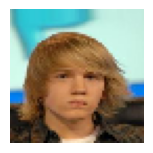

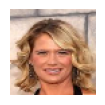

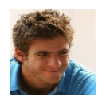

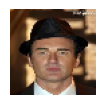

In [ ]:
#display sample images
images,_=next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.show()

In [ ]:
#encoder
input_img=Input(shape=(64,64,3))
x=Conv2D(32,(3,3),activation='relu',padding='same')(input_img) #32 filters will check one one part,3,3 is to like 3 matrix check
x=MaxPooling2D((2,2),padding='same')(x)
x=Conv2D(64,(3,3),activation='relu',padding='same')(x)
encoded=MaxPooling2D((2,2),padding='same')(x)  #2,2 for 2 matrix check


In [ ]:
#decoder
x=Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=UpSampling2D((2,2))(x) #upsam means to high that value 32=64=96 in this way
decoded=Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)


In [ ]:
autoencoder=Model(input_img,decoded)


In [ ]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')       #adam predict the weight of model,#binary where the target have only two classes

In [ ]:
autoencoder.summary()

In [15]:
history=autoencoder.fit(
    train_generator,
    epochs=50,            #batch size will run 10 tyms
    validation_data=validation_generator,

)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 520ms/step - loss: 0.4901 - val_loss: 0.4882
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 516ms/step - loss: 0.4878 - val_loss: 0.4875
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 497ms/step - loss: 0.4865 - val_loss: 0.4860
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 505ms/step - loss: 0.4858 - val_loss: 0.4865
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 516ms/step - loss: 0.4853 - val_loss: 0.4852
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 505ms/step - loss: 0.4845 - val_loss: 0.4854
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 494ms/step - loss: 0.4845 - val_loss: 0.4861
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 508ms/step - loss: 0.4840 - val_loss: 0.4838
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 506ms/step - loss: 0.4835 - val_loss: 0.4841
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 494ms/step - loss: 0.4830 - val_loss: 0.4830
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 507ms/step - loss: 0.4835 - val_loss: 0.4842
Epoch 12/50
125/125

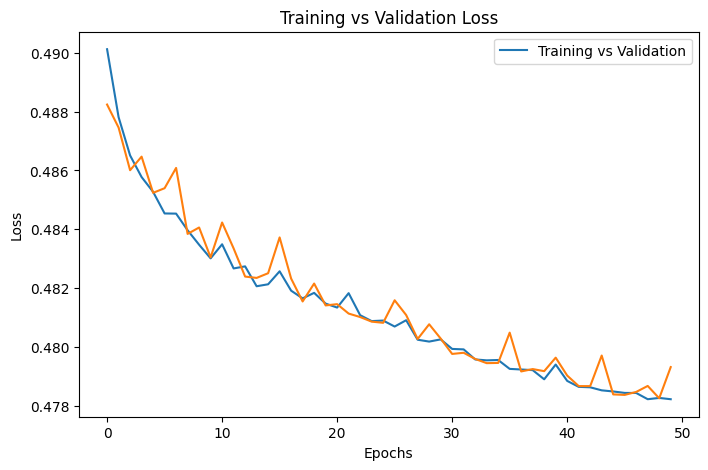

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training vs Validation Loss")
plt.legend(["Training vs Validation"])
plt.show()

In [17]:
loss=autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.4793
Validation Loss: 0.4793192148208618


In [18]:
images,_=next(validation_generator)
reconstructed=autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


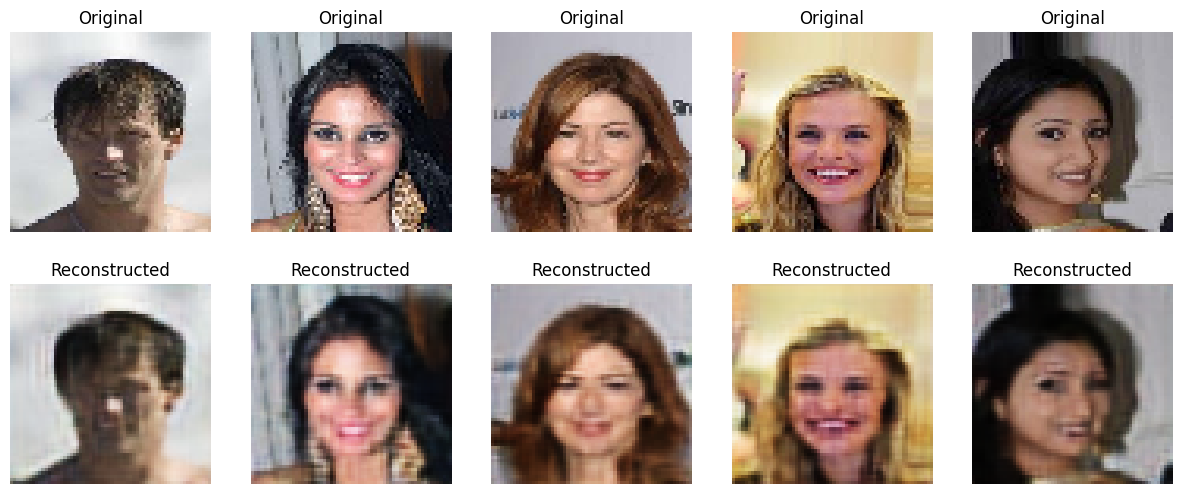

In [19]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title("Original")
    plt.subplot(2,n,i+n+1)
    plt.imshow(reconstructed[i])
    plt.axis("off")
    plt.title("Reconstructed")
plt.show()